In [4]:
!pip install python-dotenv


[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip


In [2]:
# from langchain.chat_models import AzureChatOpenAI
# from langchain_openai import AzureOpenAI

# from langchain import PromptTemplate, LLMChain
import os
import json
import warnings
warnings.filterwarnings("ignore")
import random

In [10]:
from openai import OpenAI
import requests

In [3]:
import base64
from mimetypes import guess_type

In [1]:
from dotenv import load_dotenv
load_dotenv("../.env")

False

In [35]:
from haystack.nodes import PromptModel

Data URL: 

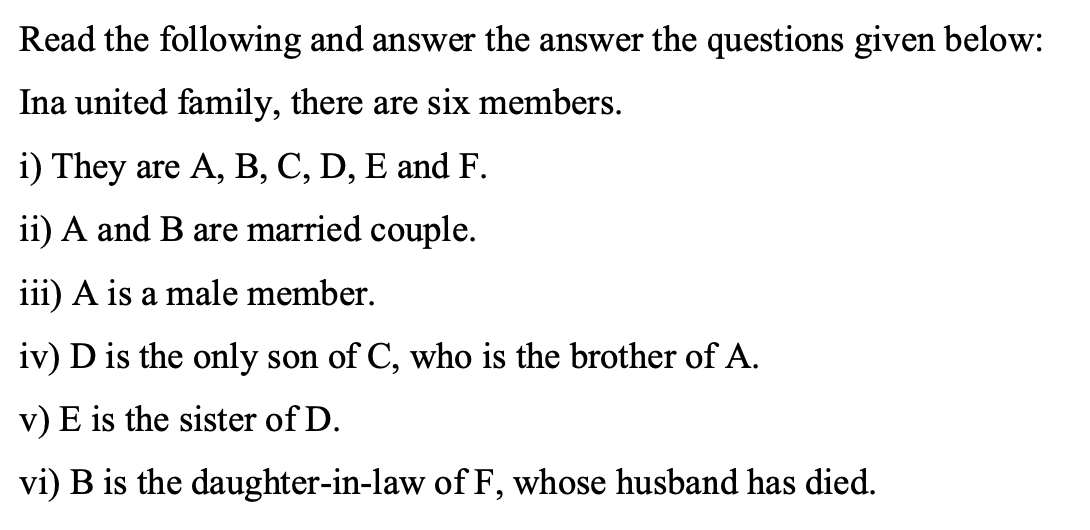

In [4]:


# Function to encode a local image into data URL 
def local_image_to_data_url(image_path):
    # Guess the MIME type of the image based on the file extension
    mime_type, _ = guess_type(image_path)
    if mime_type is None:
        mime_type = 'application/octet-stream'  # Default MIME type if none is found

    # Read and encode the image file
    with open(image_path, "rb") as image_file:
        base64_encoded_data = base64.b64encode(image_file.read()).decode('utf-8')

    # Construct the data URL
    return f"data:{mime_type};base64,{base64_encoded_data}"

# Example usage
# image_path = '/Users/shreyas.verma/Desktop/Research/PolyMATH/datastore/QP_BIHAR_NTSE_STAGE 1_MAT_2019-20/screenshots/q1_0.png'
image_path = '/Users/shreyas/Desktop/Research/PolyMATH/datastore/QP_ANDHRA PRADESH_NTSE_STAGE 1_MAT_2019-20/screenshots/c1.png'
data_url = local_image_to_data_url(image_path)
print("Data URL:", data_url)

In [50]:

headers = {
  "Content-Type": "application/json",
  "Authorization": f"Bearer {OPENAI_API_KEY_AI30}"
}

gpt_4_vision_kwargs = {
    "azure_deployment_name": "gpt-4v",
    "request_timeout": 40,
    "max_tokens": 1200,
    "top_p": 1,
    "api_version": "2023-05-15",
    "temperature": 0.3,
}


api_base = 'https://ai30.openai.azure.com' # your endpoint should look like the following https://YOUR_RESOURCE_NAME.openai.azure.com/
api_key='f546e32c18bc44089ebc572c78f4f313'
deployment_name = "gpt-4v"
api_version = '2023-12-01-preview' # this might change in the future

client = AzureOpenAI(
    api_key=api_key,  
    api_version=api_version,
    azure_endpoint=f"{api_base}/openai/deployments/{deployment_name}/extensions",
)

In [12]:
pre_image_prompt = """
What is the correct answer among the multiple choices provided, for the quesiton in the picture :
"""


In [13]:
def gen_template(ocr, grounding, highlow, base64_image):
    template = {
        "enhancements": {"ocr": {"enabled": ocr}, "grounding": {"enabled": grounding}},
        "messages": [
            {"role": "system", "content": "You are a helpful assistant."},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": pre_image_prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{base64_image}",
                                      "detail": highlow},
                    },
#                     {"type": "text", "text": post_image_prompt},
                ],
            },
        ],
        "max_tokens": 2000,
        "stream": False,
    }

    return json.dumps(template)

In [18]:
vision_template = gen_template(ocr=True, grounding=True, highlow="high",
                         base64_image=local_image_to_data_url(image_path))

In [41]:
f"{api_base}openai/deployments/{deployment_name}/extensions",

('https://ai30.openai.azure.comopenai/deployments/gpt-4v/extensions',)

In [46]:
endpoint = f"https://ai30.openai.azure.com//openai/deployments/{deployment_name}/completions?api-version={api_version}"
response = requests.post(endpoint,\
                          json=vision_template)

In [51]:
response = client.chat.completions.create(
    model=deployment_name,
    messages=[
        { "role": "system", "content": "You are a helpful assistant." },
        { "role": "user", "content": [  
            { 
                "type": "text", 
                "text": "What is the correct answer among the multiple choices provided, for the quesiton in the picture : " 
            },
            { 
                "type": "image_url",
                "image_url": {
                    "url": data_url
                }
            }
        ] } 
    ],
    max_tokens=2000 
)
print(response)

AttributeError: 'AzureOpenAI' object has no attribute 'chat'

In [47]:
print(response.json())

{'error': {'code': '401', 'message': 'Access denied due to invalid subscription key or wrong API endpoint. Make sure to provide a valid key for an active subscription and use a correct regional API endpoint for your resource.'}}


In [36]:



class RandomModel:
    model_name = None
    api_keys = []
    api_base_urls = []
    model_kwargs = {}
    models = None
    model_weights = None

    def __init__(self, model_name, model_kwargs={}):
        self.model_name = model_name
        self.model_kwargs = model_kwargs
        self.api_credentials = self.fetch_api_credentials()
        self.models = self.build_models()

    def fetch_api_credentials(self):
        potential_credentials = api_key_base_pairs.get(self.model_name)
        found_credentials = []
#         model_weights = []
        for key, base in potential_credentials:
            key_val, base_val = os.environ.get(key), os.environ.get(base)
            if not (key_val and base_val):
                print(
                    f"Did not find API credentials for: {base} in the environment variables."
                )
            else:
                print(f"Found API credentials for: {base_val}.")
                found_credentials.append((key_val, base_val))
#                 model_weights.append(weights[self.model_name][base][_env])
        if not found_credentials:
            raise Exception(f"No API credentials found for model {self.model_name}")
        return found_credentials#, model_weights

    def build_models(self):
        models = []
        for api_key, api_base in self.api_credentials:
            model_kwargs = self.model_kwargs
            max_length = model_kwargs.pop("max_length", 100)
            model_kwargs["azure_base_url"] = api_base
            models.append(
                PromptModel(
                    model_name_or_path=self.model_name,
                    api_key=api_key,
                    model_kwargs=model_kwargs,
                    max_length=max_length,
                )
            )
        return models

    def fetch(self):
        return random.choices(self.models, k=1)[0]


In [37]:
azure_gpt_4_vision_long = RandomModel(
    "gpt-4-vision", model_kwargs=gpt_4_vision_kwargs
)

Found API credentials for: https://ai30.openai.azure.com.


In [40]:
azure_gpt_4_vision_long.fetch()

PromptModel({'_component_config': {'params': {'model_name_or_path': 'gpt-4-vision', 'api_key': 'f546e32c18bc44089ebc572c78f4f313', 'model_kwargs': {'azure_deployment_name': 'gpt-4v', 'request_timeout': 40, 'max_tokens': 1200, 'top_p': 1, 'api_version': '2023-05-15', 'temperature': 0.3, 'azure_base_url': 'https://ai30.openai.azure.com'}, 'max_length': 100}, 'type': 'PromptModel'}, 'outgoing_edges': 1, 'model_name_or_path': 'gpt-4-vision', 'max_length': 100, 'api_key': 'f546e32c18bc44089ebc572c78f4f313', 'use_auth_token': None, 'use_gpu': None, 'devices': None, 'model_kwargs': {'azure_deployment_name': 'gpt-4v', 'request_timeout': 40, 'max_tokens': 1200, 'top_p': 1, 'api_version': '2023-05-15', 'temperature': 0.3, 'azure_base_url': 'https://ai30.openai.azure.com'}, 'model_invocation_layer': <haystack.nodes.prompt.invocation_layer.azure_chatgpt.AzureChatGPTInvocationLayer object at 0x2c9929210>})

In [52]:
from openai import AzureOpenAI

# api_base = os.getenv("AZURE_OPENAI_ENDPOINT")
# api_key= os.getenv("AZURE_OPENAI_API_KEY")


deployment_name = "gpt-4v"
api_version = '2023-12-01-preview' # this might change in the future

client = AzureOpenAI(
    api_key=api_key,  
    api_version=api_version,
    base_url=f"{api_base}/openai/deployments/{deployment_name}"
)

In [63]:
response = client.chat.completions.create(
    model=deployment_name,
    messages=[
        { "role": "system", "content": "You are a helpful assistant." },
        { "role": "user", "content": [  
            { 
                "type": "text", 
                "text": "What is the correct answer among the multiple choices provided, for the quesiton in the picture. NOTE : The answer is surely one amongst the four choices provided" 
            },
            { 
                "type": "image_url",
                "image_url": {
                    "url": data_url
                }
            }
        ] } 
    ],
    max_tokens=2000 
)
print(response)

ChatCompletion(id='chatcmpl-9Mk38phdJL5esXz6V14DGwS4Tg6fg', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='The correct answer is option (2) N. \n\nIn the given figure, the sequence of alphabets follows a certain pattern: \n- E (5) to H (8) is an increase of 3 places, \n- H (8) to M (13) is an increase of 5 places.\n- Similarly in the second row, B (2) to F (6) is an increase of 4 places, \n- F (6) to L (12) is an increase of 6 places.\n- Following the same pattern, in the third row, I (9) should be followed by an increase of 5 places, which gives N (14), and then N (14) should be followed by an increase of 7 places, which gives U (21).\n\nTherefore, the missing alphabet in the sequence is N.', role='assistant', function_call=None, tool_calls=None), content_filter_results={'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence

In [64]:
print(response.choices[0].message.content)

The correct answer is option (2) N. 

In the given figure, the sequence of alphabets follows a certain pattern: 
- E (5) to H (8) is an increase of 3 places, 
- H (8) to M (13) is an increase of 5 places.
- Similarly in the second row, B (2) to F (6) is an increase of 4 places, 
- F (6) to L (12) is an increase of 6 places.
- Following the same pattern, in the third row, I (9) should be followed by an increase of 5 places, which gives N (14), and then N (14) should be followed by an increase of 7 places, which gives U (21).

Therefore, the missing alphabet in the sequence is N.


In [60]:
response.json()['choices']

TypeError: string indices must be integers